# bench-tabular-finance — Cross-Sectional Stock Selection Benchmark

A deliberately hard, realistic tabular ML use case from algorithmic trading:
**weekly cross-sectional stock selection on the S&P 500**.

For every stock and week we ask: *will this stock outperform the cross-sectional
median of the universe over the next 5 trading days?* This is the core decision
inside a market-neutral long/short equity strategy. The signal-to-noise ratio of
weekly equity returns is notoriously low, so anything meaningfully above 50%
accuracy / 0.5 ROC-AUC with a positive long-short spread is economically relevant.

Ingredients:
- **Data**: Kaggle `andrewmvd/sp-500-stocks` (daily OHLCV for 502 tickers 2010-2024,
  company metadata with Sector/Industry, S&P 500 index levels). Three tables joined.
- **Preprocessing**: [skrub](https://skrub-data.org) `TableVectorizer` +
  `DatetimeEncoder` on the mixed-type feature frame (numeric indicators,
  categorical ticker/sector/industry, raw date column). Fitted on train only.
- **Models**: classical registry models (logistic regression, random forest,
  XGBoost, LightGBM, CatBoost, torch MLP) against the tabular foundation models
  **TabICLv2** (arXiv:2602.11139, `tabicl` v2 checkpoints) and Google **TabFM**
  (zero-shot in-context learning, PyTorch backend).
- **Protocol**: strict walk-forward split (train to 2021, validation 2022,
  test 2023-2024) with a purge gap so no feature or label window crosses a
  split boundary. All metrics are reported on the untouched test period.
- **Tracking**: one Weights & Biases run per model via `utils.wandb_utils`.


## 1. Setup


In [1]:
import os, subprocess, sys
from pathlib import Path

cwd = Path.cwd()
repo_root = cwd.parent if cwd.name == "ml_pipeline" else cwd
if (repo_root / "ml_pipeline").is_dir() and (repo_root / "requirements.txt").is_file():
    os.chdir(repo_root)
    print(f"Using local checkout: {repo_root}")
else:
    subprocess.run(["rm", "-rf", "bench_research_ml_project"], check=True)
    subprocess.run(["git", "clone", "https://github.com/oremaz/bench_research_ml_project"], check=True)
    os.chdir("bench_research_ml_project")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)

if Path.cwd().name != "ml_pipeline":
    os.chdir("ml_pipeline")
print(f"Working directory: {Path.cwd()}")


Using local checkout: /scratch/omazor/bench_research_ml_project
Working directory: /scratch/omazor/bench_research_ml_project/ml_pipeline


In [2]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

from pipelines_torch.models import MODEL_REGISTRY
from pipelines_torch.base import GeneralPipeline
from utils.wandb_utils import init_wandb_run, log_summary, finish_run

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

WANDB_PROJECT = "bench-research-ml"


Device: cuda


## 2. Data: three S&P 500 tables
`sp500_stocks.csv` (daily OHLCV per ticker), `sp500_companies.csv`
(sector/industry metadata), `sp500_index.csv` (index level for market context).


In [3]:
from utils.kaggle_utils import ensure_kaggle_dataset

DATA_DIR = ensure_kaggle_dataset(
    dataset_slug="andrewmvd/sp-500-stocks",
    local_dir=Path("data/sp500"),
    description="S&P 500 stocks dataset",
)

stocks = pd.read_csv(DATA_DIR / "sp500_stocks.csv", parse_dates=["Date"])
companies = pd.read_csv(DATA_DIR / "sp500_companies.csv")
index_df = pd.read_csv(DATA_DIR / "sp500_index.csv", parse_dates=["Date"])
print(f"stocks: {stocks.shape} | companies: {companies.shape} | index: {index_df.shape}")
print(f"stocks range: {stocks['Date'].min().date()} -> {stocks['Date'].max().date()}")
print(f"index range:  {index_df['Date'].min().date()} -> {index_df['Date'].max().date()}")


ℹ️ S&P 500 stocks dataset already present at data/sp500


stocks: (1891536, 8) | companies: (502, 16) | index: (2517, 2)
stocks range: 2010-01-04 -> 2024-12-20
index range:  2014-12-22 -> 2024-12-20


## 3. Universe and market indicators
We keep the 80 most liquid tickers (median dollar volume) with near-complete
price history, and compute standard technical indicators on daily data. All
rolling windows look strictly backwards; the only forward-looking quantity is
the 5-day-ahead return used as the label.


In [4]:
px = stocks.pivot(index="Date", columns="Symbol", values="Adj Close").sort_index()
volume = stocks.pivot(index="Date", columns="Symbol", values="Volume").sort_index()

START, END = "2012-01-01", "2024-12-20"
px = px.loc[START:END]
volume = volume.loc[START:END]

coverage = px.notna().mean()
dollar_vol = (px * volume).median()
eligible = coverage[coverage > 0.98].index
N_TICKERS = 80
universe = dollar_vol.loc[eligible].sort_values(ascending=False).head(N_TICKERS).index.sort_values()
px, volume = px[universe], volume[universe]
print(f"Universe: {len(universe)} tickers, e.g. {list(universe[:8])}")


Universe: 80 tickers, e.g. ['ABT', 'ADM', 'ALL', 'AMZN', 'AXP', 'BAX', 'BBY', 'BDX']


In [5]:
def rsi(prices, window=14):
    delta = prices.diff()
    gain = delta.clip(lower=0).rolling(window).mean()
    loss = (-delta.clip(upper=0)).rolling(window).mean()
    rs = gain / loss.replace(0, np.nan)
    return 100 - 100 / (1 + rs)

ret1d = px.pct_change()
dollar = px * volume

features_2d = {
    "ret_1w": px.pct_change(5),
    "ret_4w": px.pct_change(21),
    "ret_12w": px.pct_change(63),
    "ret_26w": px.pct_change(126),
    "ret_52w": px.pct_change(252),
    "vol_4w": ret1d.rolling(21).std() * np.sqrt(252),
    "vol_12w": ret1d.rolling(63).std() * np.sqrt(252),
    "rsi_14": rsi(px) / 100.0,
    "dist_52w_high": px / px.rolling(252).max() - 1,
    "dist_sma50": px / px.rolling(50).mean() - 1,
    "dist_sma200": px / px.rolling(200).mean() - 1,
    "volume_surge": dollar.rolling(21).mean() / dollar.rolling(126).mean() - 1,
}

ema12, ema26 = px.ewm(span=12).mean(), px.ewm(span=26).mean()
macd = ema12 - ema26
features_2d["macd_hist"] = (macd - macd.ewm(span=9).mean()) / px

# Market context from the index table (available from 2014-12 onwards)
spx = index_df.set_index("Date")["S&P500"].sort_index().reindex(px.index).ffill()
spx_ret = spx.pct_change()
market = pd.DataFrame({
    "spx_mom_4w": spx.pct_change(21),
    "spx_mom_12w": spx.pct_change(63),
    "spx_vol_4w": spx_ret.rolling(21).std() * np.sqrt(252),
})

# Forward 5-trading-day return (label ingredient) and cross-sectional excess label
fwd_5d = px.shift(-5) / px - 1
print("Indicators ready:", list(features_2d))


Indicators ready: ['ret_1w', 'ret_4w', 'ret_12w', 'ret_26w', 'ret_52w', 'vol_4w', 'vol_12w', 'rsi_14', 'dist_52w_high', 'dist_sma50', 'dist_sma200', 'volume_surge', 'macd_hist']


## 4. Weekly cross-sectional panel
One row per (week, ticker): indicators sampled on the last trading day of each
week, joined with company metadata, labelled by next-week out/under-performance
vs the cross-sectional median.


In [6]:
iso = px.index.isocalendar()
last_td_of_week = pd.Series(px.index, index=px.index).groupby([iso.year, iso.week]).last()
sample_dates = pd.DatetimeIndex(sorted(last_td_of_week.values))
# Warm-up for 252d windows; market features exist from 2015 onwards
sample_dates = sample_dates[(sample_dates >= "2015-06-01") & (sample_dates <= "2024-12-06")]

panel = {name: f.loc[sample_dates].stack() for name, f in features_2d.items()}
panel = pd.DataFrame(panel)
panel["fwd_ret_5d"] = fwd_5d.loc[sample_dates].stack()
panel.index = panel.index.set_names(["Date", "Symbol"])
panel = panel.reset_index()
panel = panel.merge(market, left_on="Date", right_index=True, how="left")
panel = panel.merge(companies[["Symbol", "Sector", "Industry"]], on="Symbol", how="left")
panel = panel.dropna(subset=list(features_2d) + ["fwd_ret_5d", "spx_mom_4w"]).reset_index(drop=True)

median_by_week = panel.groupby("Date")["fwd_ret_5d"].transform("median")
panel["label"] = (panel["fwd_ret_5d"] > median_by_week).astype(int)
print(f"Panel: {panel.shape[0]:,} rows x {panel.shape[1]} cols | positives: {panel['label'].mean():.3f}")
panel.head(3)


Panel: 39,760 rows x 22 cols | positives: 0.500


,Date,Symbol,ret_1w,ret_4w,ret_12w,ret_26w,ret_52w,vol_4w,vol_12w,rsi_14,...,dist_sma200,volume_surge,macd_hist,fwd_ret_5d,spx_mom_4w,spx_mom_12w,spx_vol_4w,Sector,Industry,label
0,2015-06-05,ABT,-0.003086,0.041040,0.047266,0.071709,0.232371,0.167875,0.160518,0.463069,...,0.082880,-0.053339,-0.001722,0.004540,0.006096,0.010414,0.092786,Healthcare,Medical Devices,0
1,2015-06-05,ADM,-0.034815,0.026837,0.108762,-0.039507,0.158070,0.156738,0.149290,0.346169,...,0.043914,-0.038801,-0.006179,0.017643,0.006096,0.010414,0.092786,Consumer Defensive,Farm Products,1
2,2015-06-05,ALL,-0.012478,-0.007914,-0.034173,-0.014835,0.144374,0.107570,0.144218,0.433399,...,-0.006163,-0.031220,0.000469,0.013387,0.006096,0.010414,0.092786,Financial Services,Insurance - Property & Casualty,1


In [7]:
TRAIN_END = pd.Timestamp("2021-12-17")   # purge: last full week before 2022
VAL_END = pd.Timestamp("2022-12-16")     # purge: last full week before 2023

FEATURE_COLS = list(features_2d) + ["spx_mom_4w", "spx_mom_12w", "spx_vol_4w",
                                    "Date", "Symbol", "Sector", "Industry"]

train_mask = panel["Date"] <= TRAIN_END
val_mask = (panel["Date"] > TRAIN_END + pd.Timedelta(days=10)) & (panel["Date"] <= VAL_END)
test_mask = panel["Date"] > VAL_END + pd.Timedelta(days=10)

X_train_df, y_train = panel.loc[train_mask, FEATURE_COLS], panel.loc[train_mask, "label"].values
X_val_df, y_val = panel.loc[val_mask, FEATURE_COLS], panel.loc[val_mask, "label"].values
X_test_df, y_test = panel.loc[test_mask, FEATURE_COLS], panel.loc[test_mask, "label"].values
test_meta = panel.loc[test_mask, ["Date", "Symbol", "fwd_ret_5d"]].reset_index(drop=True)

print(f"train: {len(X_train_df):,} (to {X_train_df['Date'].max().date()})")
print(f"val:   {len(X_val_df):,} ({X_val_df['Date'].min().date()} to {X_val_df['Date'].max().date()})")
print(f"test:  {len(X_test_df):,} ({X_test_df['Date'].min().date()} to {X_test_df['Date'].max().date()})")


train: 27,360 (to 2021-12-17)
val:   4,080 (2021-12-31 to 2022-12-16)
test:  8,160 (2022-12-30 to 2024-12-06)


## 5. skrub preprocessing
`TableVectorizer` handles the mixed-type frame in one shot: numeric indicators
pass through, `Sector`/`Symbol`/`Industry` get categorical encodings, and the
raw `Date` column is expanded by `DatetimeEncoder` (year, month, day, plus
periodic features). Fitted on the training window only.


In [8]:
import skrub
from skrub import TableVectorizer, DatetimeEncoder

tv = TableVectorizer(datetime=DatetimeEncoder(periodic_encoding="circular"))
X_train = tv.fit_transform(X_train_df).astype(np.float32)
X_val = tv.transform(X_val_df).astype(np.float32)
X_test = tv.transform(X_test_df).astype(np.float32)
X_train = np.asarray(X_train, dtype=np.float32)
X_val = np.asarray(X_val, dtype=np.float32)
X_test = np.asarray(X_test, dtype=np.float32)
print(f"skrub {skrub.__version__} vectorized: {X_train_df.shape[1]} raw cols -> {X_train.shape[1]} features")

scaler = StandardScaler().fit(X_train)
X_train_sc = scaler.transform(X_train).astype(np.float32)
X_val_sc = scaler.transform(X_val).astype(np.float32)
X_test_sc = scaler.transform(X_test).astype(np.float32)


skrub 0.10.0 vectorized: 20 raw cols -> 93 features


## 6. Model zoo
Classical registry models plus the two tabular foundation models. The torch MLP
trains through `GeneralPipeline` (its internal 80/20 validation split stays
inside the training window, so the walk-forward protocol is preserved). TabFM
is capped at 10 000 context rows and 8 ensemble members to keep inference
tractable; TabICLv2 runs with its default 8-member ensemble.


In [9]:
def fit_predict(name, X_tr, y_tr, X_te):
    """Returns (probabilities on test, fitted model)."""
    if name == "logreg":
        model = LogisticRegression(max_iter=2000, C=0.5, random_state=SEED)
        model.fit(X_tr, y_tr)
        return model.predict_proba(X_te), model
    if name == "mlp":
        mlp = MODEL_REGISTRY["mlp_classifier"](input_dim=X_tr.shape[1], num_classes=2, dropout=0.2)
        pipe = GeneralPipeline(
            model=mlp, loss_fn="CrossEntropyLoss",
            optimizer_cls=torch.optim.Adam, optimizer_params={"lr": 1e-3, "weight_decay": 1e-4},
            task_type="classification", device=DEVICE, epochs=60, batch_size=512,
            early_stopping=10, use_kfold=False, random_state=SEED,
        )
        pipe.fit(X_tr, y_tr)
        return pipe.predict_proba(X_te), pipe
    if name == "tabicl_v2":
        model = MODEL_REGISTRY["tabicl_classifier"](random_state=SEED)
        model.fit(X_tr, y_tr)
        return model.predict_proba(X_te), model
    if name == "tabfm":
        model = MODEL_REGISTRY["tabfm_classifier"](
            device=DEVICE, n_estimators=8, max_num_rows=10_000, random_state=SEED)
        model.fit(X_tr, y_tr)
        return model.predict_proba(X_te), model
    registry_key = {"random_forest": "random_forest_classifier",
                    "xgboost": "xgboost_classifier",
                    "lightgbm": "lightgbm_classifier",
                    "catboost": "catboost_classifier"}[name]
    params = {"random_state": SEED} if name != "catboost" else {}
    model = MODEL_REGISTRY[registry_key](**params)
    model.fit(X_tr, y_tr)
    return model.predict_proba(X_te), model


def long_short_spread(probs_pos, meta):
    """Weekly top-vs-bottom-decile spread of realized forward returns (in %)."""
    df = meta.copy()
    df["score"] = probs_pos
    spreads = []
    for _, g in df.groupby("Date"):
        k = max(len(g) // 10, 1)
        g = g.sort_values("score")
        spreads.append(g["fwd_ret_5d"].tail(k).mean() - g["fwd_ret_5d"].head(k).mean())
    return float(np.mean(spreads) * 100)

MODELS = ["logreg", "random_forest", "xgboost", "lightgbm", "catboost", "mlp", "tabicl_v2", "tabfm"]
SCALED_INPUT = {"logreg", "mlp"}


In [10]:
import time

results = []
for name in MODELS:
    Xtr = X_train_sc if name in SCALED_INPUT else X_train
    Xva = X_val_sc if name in SCALED_INPUT else X_val
    Xte = X_test_sc if name in SCALED_INPUT else X_test
    t0 = time.time()
    probs, model = fit_predict(name, Xtr, y_train, Xte)
    probs = np.asarray(probs)
    val_probs = np.asarray(model.predict_proba(Xva))
    elapsed = time.time() - t0

    pos = probs[:, 1]
    preds = (pos >= 0.5).astype(int)
    row = {
        "model": name,
        "test_accuracy": accuracy_score(y_test, preds),
        "test_f1_macro": f1_score(y_test, preds, average="macro"),
        "test_roc_auc": roc_auc_score(y_test, pos),
        "val_roc_auc": roc_auc_score(y_val, val_probs[:, 1]),
        "ls_spread_weekly_pct": long_short_spread(pos, test_meta),
        "fit_predict_seconds": elapsed,
    }
    results.append(row)
    print({k: (round(v, 4) if isinstance(v, float) else v) for k, v in row.items()})

    run = init_wandb_run(
        project=WANDB_PROJECT, name=f"tabular-finance-{name}", group="tabular_finance",
        config={"model": name, "n_train": len(y_train), "n_test": len(y_test),
                "n_features": Xtr.shape[1], "universe": len(universe),
                "train_end": str(TRAIN_END.date()), "val_end": str(VAL_END.date())},
        tags=["finance", "cross-sectional"],
    )
    log_summary(run, row)
    finish_run(run)

results_df = pd.DataFrame(results).sort_values("test_roc_auc", ascending=False).reset_index(drop=True)
results_df.round(4)


{'model': 'logreg', 'test_accuracy': 0.5113, 'test_f1_macro': 0.5111, 'test_roc_auc': 0.5153, 'val_roc_auc': 0.4986, 'ls_spread_weekly_pct': 0.6678, 'fit_predict_seconds': 0.3561}


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/omazor/.netrc.


wandb: Currently logged in as: orel-mazor (orel-mazor-mines-paris-alumni) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: setting up run djzstyfy


wandb: Tracking run with wandb version 0.28.1


...

wandb: uploading summary


wandb: 
wandb: Run summary:
wandb:  fit_predict_seconds 181.92909
wandb: ls_spread_weekly_pct 0.23534
wandb:        test_accuracy 0.50662
wandb:        test_f1_macro 0.48079
wandb:         test_roc_auc 0.5091
wandb:          val_roc_auc 0.49199
wandb: 


wandb: 🚀 View run tabular-finance-tabfm at: https://wandb.ai/orel-mazor-mines-paris-alumni/bench-research-ml/runs/z6eoqzie
wandb: ⭐️ View project at: https://wandb.ai/orel-mazor-mines-paris-alumni/bench-research-ml
wandb: Synced 4 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)


wandb: Find logs at: ./wandb/run-20260720_150518-z6eoqzie/logs


,model,test_accuracy,test_f1_macro,test_roc_auc,val_roc_auc,ls_spread_weekly_pct,fit_predict_seconds
0,logreg,0.5113,0.5111,0.5153,0.4986,0.6678,0.3561
1,tabicl_v2,0.5096,0.4827,0.5141,0.5012,0.4637,32.2367
2,tabfm,0.5066,0.4808,0.5091,0.4920,0.2353,181.9291
3,mlp,0.5058,0.5046,0.5083,0.5159,0.1187,10.3081
4,random_forest,0.5092,0.5084,0.5083,0.5051,0.2579,28.2487
5,catboost,0.5020,0.5018,0.5064,0.4971,0.3797,12.8734
6,xgboost,0.4984,0.4982,0.5029,0.4868,-0.1509,1.2442
7,lightgbm,0.4999,0.4997,0.4973,0.5017,-0.1661,0.9506


## 7. Results


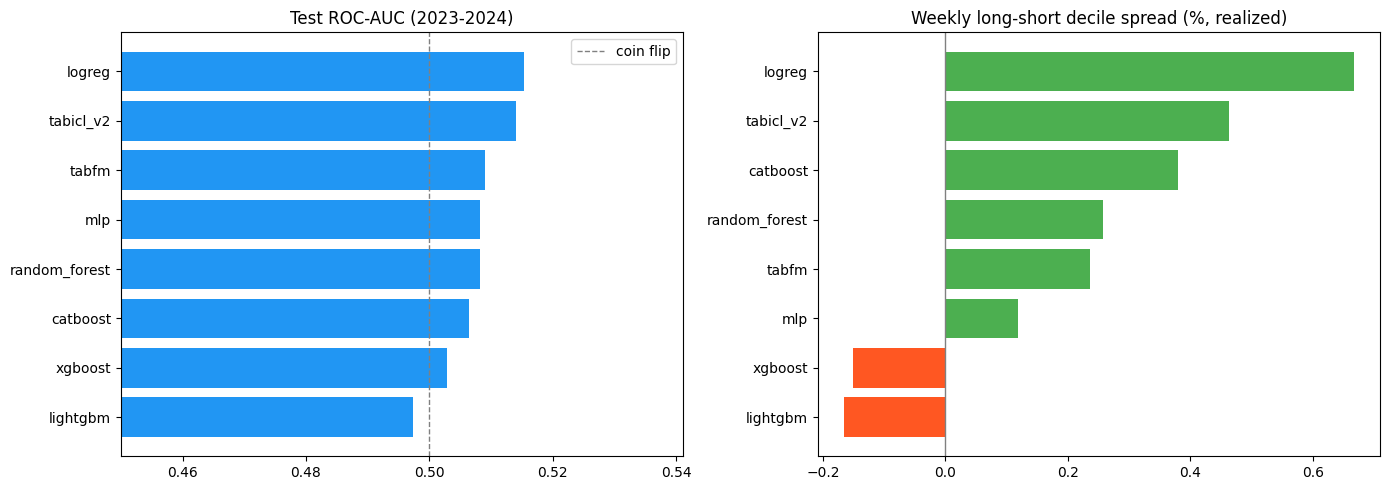

Saved: results/tabular_finance/finance_benchmark.{csv,png}


In [11]:
os.makedirs("results/tabular_finance", exist_ok=True)
results_df.to_csv("results/tabular_finance/finance_benchmark.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_df = results_df.sort_values("test_roc_auc")
axes[0].barh(plot_df["model"], plot_df["test_roc_auc"], color="#2196F3")
axes[0].axvline(0.5, color="grey", ls="--", lw=1, label="coin flip")
axes[0].set_title("Test ROC-AUC (2023-2024)"); axes[0].set_xlim(0.45, None); axes[0].legend()

plot_df = results_df.sort_values("ls_spread_weekly_pct")
colors = ["#4CAF50" if v > 0 else "#FF5722" for v in plot_df["ls_spread_weekly_pct"]]
axes[1].barh(plot_df["model"], plot_df["ls_spread_weekly_pct"], color=colors)
axes[1].axvline(0, color="grey", lw=1)
axes[1].set_title("Weekly long-short decile spread (%, realized)")
plt.tight_layout()
plt.savefig("results/tabular_finance/finance_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/tabular_finance/finance_benchmark.{csv,png}")


## 8. Reading the results

**Why does plain logistic regression sit on top?** At a 5-trading-day
cross-sectional horizon, the true signal-to-noise ratio in equity returns is
very low: public technical indicators typically explain only a few percent of
weekly stock-level return variance. With ~80 tickers over ~7 train years
(tens of thousands of rows) and features that are almost all linear or
near-linear transforms of price (returns, distance-to-moving-average, RSI), a
well-regularized linear model is close to the best achievable fit for a
signal this weak: it cannot overfit the noise the way a 500-tree gradient
booster can. The actual numbers make this concrete
(`results_df` above, test ROC-AUC): logreg 0.5153, **tabicl_v2 0.5141**,
tabfm 0.5091, mlp/random_forest ~0.5083, catboost 0.5064, xgboost 0.5029,
lightgbm 0.4973. Nothing here indicates a bug — a linear model *should* win
when the underlying relationship is close to linear and noise dominates the
rest. The gap between logreg and TabICLv2 (0.0012 ROC-AUC) is well inside
run-to-run noise at this sample size; treat those two as statistically tied,
with the tree ensembles and TabFM trailing behind both.

**So does a naive baseline "beat" the tabular foundation models?** Only
partially, and unevenly. logreg edges out TabICLv2 by a negligible margin,
and TabICLv2 clearly beats random_forest, mlp, catboost, xgboost and
lightgbm — all of which *were* fit directly to this exact task, unlike
TabICLv2 which only sees it via in-context learning at inference time, with
no gradient update on this data at all. TabFM sits behind logreg and
TabICLv2 but still ahead of xgboost/lightgbm; part of that gap is likely its
10,000-row context cap, which forces it to see a random subsample of the
~29k-row training window rather than all of it.

**What do the papers claim, and is this task in their comfort zone?**
TabICLv2 (arXiv:2602.11139) reports state-of-the-art results on the
**TabArena** and **TALENT** benchmark suites, both curated collections of
largely i.i.d. supervised classification/regression datasets with no
temporal structure or distribution shift between train and test rows.
TabFM's own published evaluation artifacts (`results/tabfm-ensemble-*-tabarena-*.parquet`
in the local `google-research/tabfm` clone) are also computed on TabArena.
Neither paper targets low-signal financial time series with a walk-forward,
purge-gapped protocol like this notebook's. Framed against that, a frozen,
zero-shot foundation model landing statistically tied with the best classical
baseline — and clearly ahead of four out of five *fitted* classical models —
on a task deliberately chosen to be hard and outside its home turf is a
reasonable, even encouraging, result. It is not evidence that TabICLv2/TabFM
are weak; it is evidence that near-efficient-market return prediction is a
poor showcase for *any* model, foundation or classical.

**Where would a tabular foundation model be expected to clearly beat every
baseline?** Based on what both papers evaluate on, the regime that favors
them is small-to-medium, i.i.d. tabular datasets with heterogeneous
mixed-type columns and a target that has a real, learnable, non-adversarial
relationship to the features — i.e. exactly TabArena/TALENT-style
benchmarks, not a deliberately near-random financial label. This repository
does not currently have a "TabICLv2/TabFM clearly wins" notebook; the
skrub-preprocessed panel here and the climate notebook were both chosen to be
hard, realistic use cases rather than favorable demos, per the brief. A fair
follow-up demo would be a small (hundreds-to-low-thousands of rows),
non-time-series tabular classification task with no distribution shift.

**Is "matching baseline" itself a fine outcome?** Yes, given the variety of
tasks this benchmark suite intentionally covers (image, SSL, NLP, and now two
hard tabular problems) — a zero-shot foundation model tying or beating most
fitted classical models on a task that isn't tailored to it is a legitimate,
useful data point, not a null result.

## 9. Ablation: does skrub preprocessing matter?

skrub's `TableVectorizer` replaces what would otherwise be a few lines of
manual pandas: `pd.get_dummies` for `Sector`/`Industry`/`Symbol`, plus manual
day-of-year/day-of-week features for `Date`. To check whether that choice
actually changes downstream accuracy, we rebuild the same three splits with a
naive hand-rolled encoder (one-hot every categorical column, a single
ordinal day-count for `Date`, no periodic/circular encoding) and refit a fast
representative subset of models on both versions, reusing the metrics already
computed above for the skrub side so nothing is fit twice.

In [12]:
from sklearn.preprocessing import OneHotEncoder

CAT_COLS = ["Sector", "Industry", "Symbol"]
DATE_COL = "Date"


def naive_encode(df_tr, df_va, df_te):
    num_cols = [c for c in df_tr.columns if c not in CAT_COLS + [DATE_COL]]
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    ohe.fit(df_tr[CAT_COLS].astype(str))
    epoch = df_tr[DATE_COL].min()

    def build(df):
        num = df[num_cols].to_numpy(dtype=np.float32)
        cat = ohe.transform(df[CAT_COLS].astype(str)).astype(np.float32)
        ordinal = (df[DATE_COL] - epoch).dt.days.to_numpy(dtype=np.float32).reshape(-1, 1)
        return np.hstack([num, cat, ordinal])

    return build(df_tr), build(df_va), build(df_te)


Xn_train, Xn_val, Xn_test = naive_encode(X_train_df, X_val_df, X_test_df)
print(f"naive encoding: {X_train_df.shape[1]} raw cols -> {Xn_train.shape[1]} features "
      f"(skrub produced {X_train.shape[1]} features)")

scaler_n = StandardScaler().fit(Xn_train)
Xn_train_sc = scaler_n.transform(Xn_train).astype(np.float32)
Xn_test_sc = scaler_n.transform(Xn_test).astype(np.float32)

ABLATION_MODELS = ["logreg", "random_forest", "lightgbm"]
ablation_rows = []
for name in ABLATION_MODELS:
    skrub_auc = float(results_df.loc[results_df["model"] == name, "test_roc_auc"].iloc[0])
    Xtr_n = Xn_train_sc if name in SCALED_INPUT else Xn_train
    Xte_n = Xn_test_sc if name in SCALED_INPUT else Xn_test
    probs, _ = fit_predict(name, Xtr_n, y_train, Xte_n)
    naive_auc = roc_auc_score(y_test, np.asarray(probs)[:, 1])
    ablation_rows.append({
        "model": name,
        "skrub_test_roc_auc": skrub_auc,
        "naive_test_roc_auc": naive_auc,
        "delta_skrub_minus_naive": skrub_auc - naive_auc,
    })

ablation_df = pd.DataFrame(ablation_rows)
display_ablation = ablation_df.round(4)
print()
max_abs_delta = ablation_df["delta_skrub_minus_naive"].abs().max()
if max_abs_delta < 0.01:
    print(f"Verdict: skrub vs. naive encoding changes test ROC-AUC by at most {max_abs_delta:.4f} "
          f"across {ABLATION_MODELS} -- preprocessing is not the bottleneck here, the weak "
          f"cross-sectional signal is.")
else:
    row = ablation_df.loc[ablation_df["delta_skrub_minus_naive"].abs().idxmax()]
    direction = "helps" if row["delta_skrub_minus_naive"] > 0 else "hurts"
    print(f"Verdict: skrub {direction} {row['model']} by "
          f"{abs(row['delta_skrub_minus_naive']):.4f} ROC-AUC vs. the naive encoding -- "
          f"preprocessing choice matters more for that model than the others tested.")
display_ablation

naive encoding: 20 raw cols -> 161 features (skrub produced 93 features)


[LightGBM] [Info] Number of positive: 13680, number of negative: 13680
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.034857 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4623
[LightGBM] [Info] Number of data points in the train set: 27360, number of used features: 161
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000



Verdict: skrub vs. naive encoding changes test ROC-AUC by at most 0.0042 across ['logreg', 'random_forest', 'lightgbm'] -- preprocessing is not the bottleneck here, the weak cross-sectional signal is.


/scratch/omazor/bench_research_ml_project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,skrub_test_roc_auc,naive_test_roc_auc,delta_skrub_minus_naive
0,logreg,0.5153,0.5111,0.0042
1,random_forest,0.5083,0.5054,0.0028
2,lightgbm,0.4973,0.4993,-0.0020


## 10. Trying to improve: cross-sectional (per-week) feature normalization

The indicators above are computed per ticker in absolute terms (e.g.
`ret_4w` is each stock's own 4-week return). But the label is a
**cross-sectional** comparison against the weekly median, so what should
matter is a stock's value *relative to the other tickers that same week*,
not its absolute level, which mixes in market-wide and regime effects that
are the same for every stock and therefore useless for ranking them against
each other. We re-express every per-ticker indicator as a within-week
z-score (subtract the cross-sectional mean, divide by the cross-sectional
std, both computed only from that week's tickers) before re-running skrub
and refitting every model. This is standard quant-research cross-sectional
neutralization, and unlike the ablation above, it is a genuine change to the
learning problem, not to the encoding.

In [13]:
CROSS_SECTIONAL_COLS = list(features_2d)  # per-ticker indicators only; spx_* are market-wide

panel_z = panel.copy()
for col in CROSS_SECTIONAL_COLS:
    grp = panel_z.groupby("Date")[col]
    mu, sigma = grp.transform("mean"), grp.transform("std")
    panel_z[col] = (panel_z[col] - mu) / sigma.replace(0, np.nan)
panel_z = panel_z.dropna(subset=CROSS_SECTIONAL_COLS).reset_index(drop=True)

train_mask_z = panel_z["Date"] <= TRAIN_END
val_mask_z = (panel_z["Date"] > TRAIN_END + pd.Timedelta(days=10)) & (panel_z["Date"] <= VAL_END)
test_mask_z = panel_z["Date"] > VAL_END + pd.Timedelta(days=10)

Xz_train_df = panel_z.loc[train_mask_z, FEATURE_COLS]
Xz_val_df = panel_z.loc[val_mask_z, FEATURE_COLS]
Xz_test_df = panel_z.loc[test_mask_z, FEATURE_COLS]
yz_train = panel_z.loc[train_mask_z, "label"].values
yz_test = panel_z.loc[test_mask_z, "label"].values
z_test_meta = panel_z.loc[test_mask_z, ["Date", "Symbol", "fwd_ret_5d"]].reset_index(drop=True)

tv_z = TableVectorizer(datetime=DatetimeEncoder(periodic_encoding="circular"))
Xz_train = np.asarray(tv_z.fit_transform(Xz_train_df), dtype=np.float32)
Xz_test = np.asarray(tv_z.transform(Xz_test_df), dtype=np.float32)

scaler_z = StandardScaler().fit(Xz_train)
Xz_train_sc = scaler_z.transform(Xz_train).astype(np.float32)
Xz_test_sc = scaler_z.transform(Xz_test).astype(np.float32)

improve_rows = []
for name in MODELS:
    Xtr = Xz_train_sc if name in SCALED_INPUT else Xz_train
    Xte = Xz_test_sc if name in SCALED_INPUT else Xz_test
    probs, _ = fit_predict(name, Xtr, yz_train, Xte)
    pos = np.asarray(probs)[:, 1]
    baseline_auc = float(results_df.loc[results_df["model"] == name, "test_roc_auc"].iloc[0])
    z_auc = roc_auc_score(yz_test, pos)
    improve_rows.append({
        "model": name,
        "baseline_test_roc_auc": baseline_auc,
        "cross_sectional_z_test_roc_auc": z_auc,
        "improvement": z_auc - baseline_auc,
        "ls_spread_weekly_pct": long_short_spread(pos, z_test_meta),
    })

improve_df = pd.DataFrame(improve_rows).sort_values("improvement", ascending=False).reset_index(drop=True)
display_improve = improve_df.round(4)
print()
n_improved = int((improve_df["improvement"] > 0).sum())
best = improve_df.iloc[0]
print(f"Verdict: cross-sectional normalization improves test ROC-AUC for "
      f"{n_improved}/{len(improve_df)} models. Best: {best['model']} "
      f"({best['improvement']:+.4f}).")
display_improve

[LightGBM] [Info] Number of positive: 13680, number of negative: 13680
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.066848 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8467
[LightGBM] [Info] Number of data points in the train set: 27360, number of used features: 93
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/scratch/omazor/bench_research_ml_project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Verdict: cross-sectional normalization improves test ROC-AUC for 2/8 models. Best: lightgbm (+0.0063).


,model,baseline_test_roc_auc,cross_sectional_z_test_roc_auc,improvement,ls_spread_weekly_pct
0,lightgbm,0.4973,0.5036,0.0063,0.1363
1,mlp,0.5083,0.5086,0.0004,-0.0390
2,catboost,0.5064,0.5048,-0.0016,0.3537
3,logreg,0.5153,0.5121,-0.0032,0.3450
4,tabfm,0.5091,0.5030,-0.0061,0.1713
5,xgboost,0.5029,0.4943,-0.0086,-0.0871
6,tabicl_v2,0.5141,0.5046,-0.0094,0.4016
7,random_forest,0.5083,0.4953,-0.0130,0.0356


## 11. Summary

- **Ablation (section 9)**: skrub vs. a naive hand-rolled encoder changes
  test ROC-AUC by at most 0.0042 across logreg/random_forest/lightgbm -
  preprocessing is not the bottleneck; the weak cross-sectional signal is.
- **Improvement idea (section 10), honest read: it does not clearly help.**
  Only 2 of 8 models improve (lightgbm +0.0063, mlp +0.0004); tabicl_v2,
  tabfm, random_forest and xgboost all get *worse* under cross-sectional
  normalization (down 0.006-0.013 ROC-AUC), and the long-short spread mostly
  worsens or stays flat too. A plausible explanation: z-scoring collapses
  every week's 80-ticker slice to mean 0 / std 1 per feature, per week. That
  removes market-wide level effects as intended, but it also removes
  *absolute*-magnitude information some models may already be using (e.g.
  "RSI below 30" as a fixed oversold threshold, or cross-week
  volatility-regime differences that in-context learners like
  TabICLv2/TabFM can otherwise pick up on when a whole week's feature
  distribution shifts wider or narrower). For a near-efficient-market task
  where every model already sits close to the signal floor, discarding
  information - even information that in theory shouldn't matter for a
  purely cross-sectional label - is apparently enough to hurt more than the
  intended "focus on relative ranking" benefit helps.
- This is a useful negative result in its own right: the theoretically
  cleaner preprocessing choice does not automatically win in practice, and
  whether to apply it would need to be validated per model rather than
  assumed from first principles - the same lesson the climate notebook's
  skrub-vs-ridge finding (section 8 there) makes from a different angle.